In [ ]:
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/utils.R")

In [ ]:
# after changing line to use another test (ChiSq)
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/utils_plotting_DMG.R")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()   masks stats::filter()
✖ dplyr::lag()      masks stats::lag()
✖ readr::read_csv() masks anndata::read_csv()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

In [ ]:
# Local similarities of participants based on cellular environments
data$obsp <- list()
for(e in c("X_phate","X_umap","X_tsne")) 
  data$obsp[[paste0("similarity_", e)]] <- embedding.similarity(data$obsm[[e]], knn = 5)

Warning message:
“Using `all_of()` outside of a selecting function was deprecated in tidyselect 1.2.0.
ℹ See details at <https://tidyselect.r-lib.org/reference/faq-selection-context.html>”


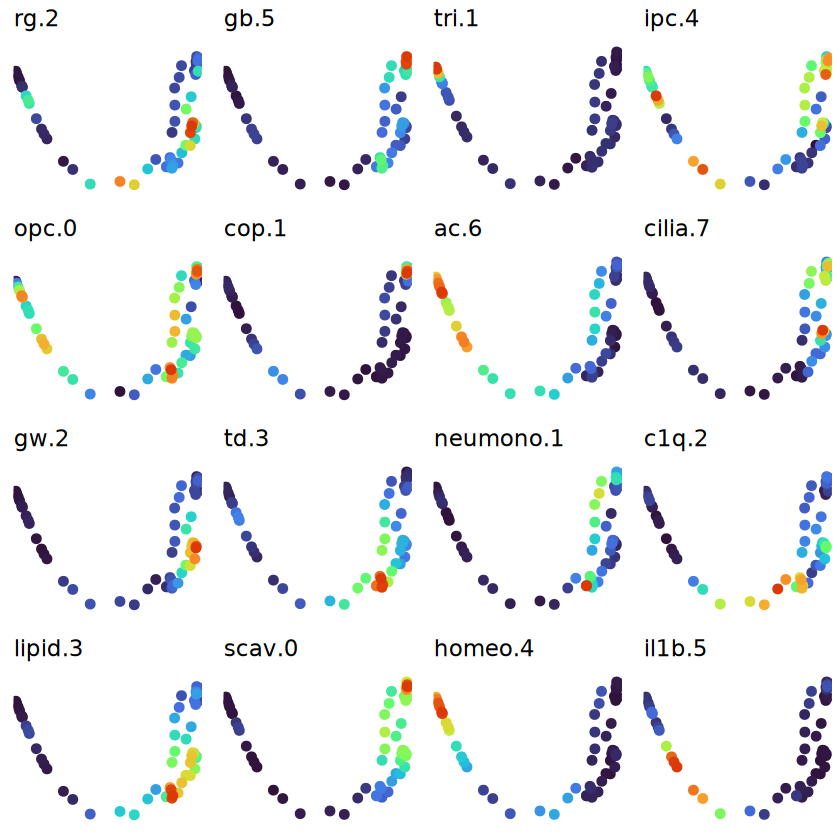

In [ ]:
plot.landscape(c('rg.2','gb.5','tri.1','ipc.4','opc.0','cop.1','ac.6','cilia.7','gw.2','td.3',
                 'neumono.1','c1q.2','lipid.3','scav.0','homeo.4','il1b.5'), 
               embedding = 'X_phate',
               enforce.same.color.scale = FALSE, smoothened = TRUE, ncol=4) 

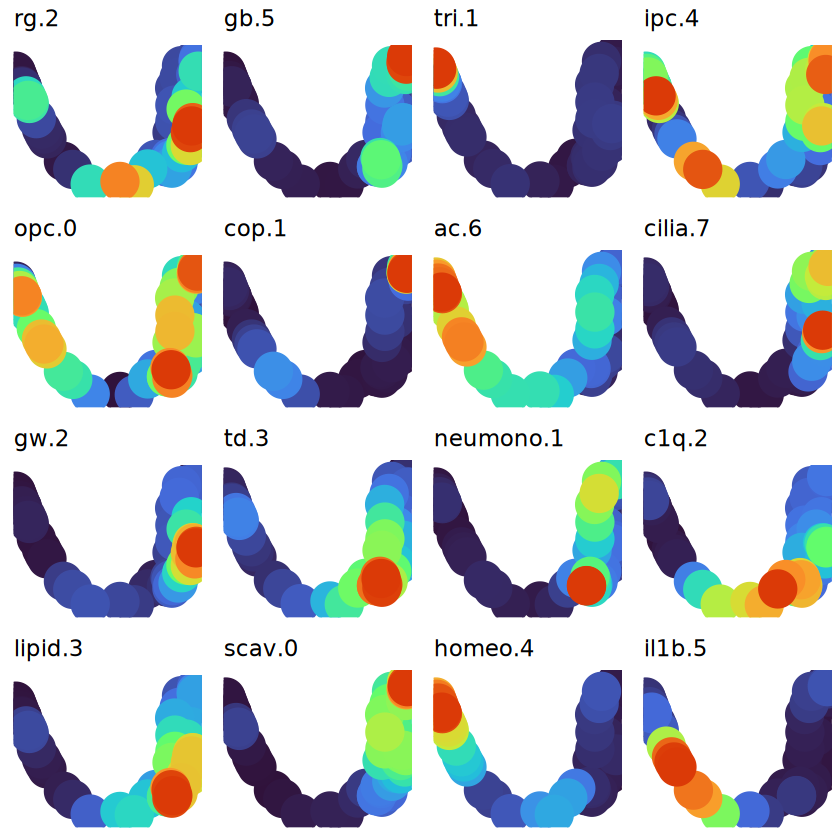

In [ ]:
plot.landscape(c('rg.2','gb.5','tri.1','ipc.4','opc.0','cop.1','ac.6','cilia.7','gw.2','td.3',
                 'neumono.1','c1q.2','lipid.3','scav.0','homeo.4','il1b.5'), 
               embedding = 'X_phate',size = 10,
               enforce.same.color.scale = FALSE, smoothened = TRUE, ncol=4) 

In [ ]:
ggsave('/projects/0/einf2548/cruiz/dmg/data/beyond/figures/phate_communities_per_celltype_DMG.pdf', 
      height=10, width=20)

In [ ]:
df <- data.frame(pseudotime=data$uns$trajectories$palantir$pseudotime,
                 entropy=apply(py_to_r(data$uns$trajectories$palantir$branch.probs), 1, function(i) -sum(i*log2(i)) %>% ifelse(is.nan(.), 0, .)),
                 py_to_r(data$uns$trajectories$palantir$branch.probs))
df

,pseudotime,entropy,clinical
,<dbl>,<dbl>,<dbl>
projid.1,0.97333111,-1.281371e-15,1
projid.10,0.81744219,-2.883084e-15,1
projid.100,0.83368690,-1.601713e-15,1
projid.101,0.79633110,-2.242399e-15,1
projid.102,0.80159411,-1.922056e-15,1
projid.11,0.90194238,-1.281371e-15,1
projid.12,0.04962191,-8.649252e-15,1
projid.13,0.14601147,-4.164454e-15,1
projid.14,0.14832134,-4.805140e-15,1


In [ ]:
library(viridis)  
library(RColorBrewer)

colors <- circlize::colorRamp2(
  seq(0, 1, length.out = 7), 
  rev(colorRampPalette(brewer.pal(11, "Spectral"))(7))
)(seq(0, 1, length.out = 7))  

In [ ]:
color_pseudotime <- colorRampPalette(colors)
color_pseudotime

function (n) 
{
    x <- ramp(seq.int(0, 1, length.out = n))
    if (ncol(x) == 4L) 
        rgb(x[, 1L], x[, 2L], x[, 3L], x[, 4L], maxColorValue = 255)
    else rgb(x[, 1L], x[, 2L], x[, 3L], maxColorValue = 255)
}
<bytecode: 0x555ef5ba9ca8>
<environment: 0x555ef7f87ce8>

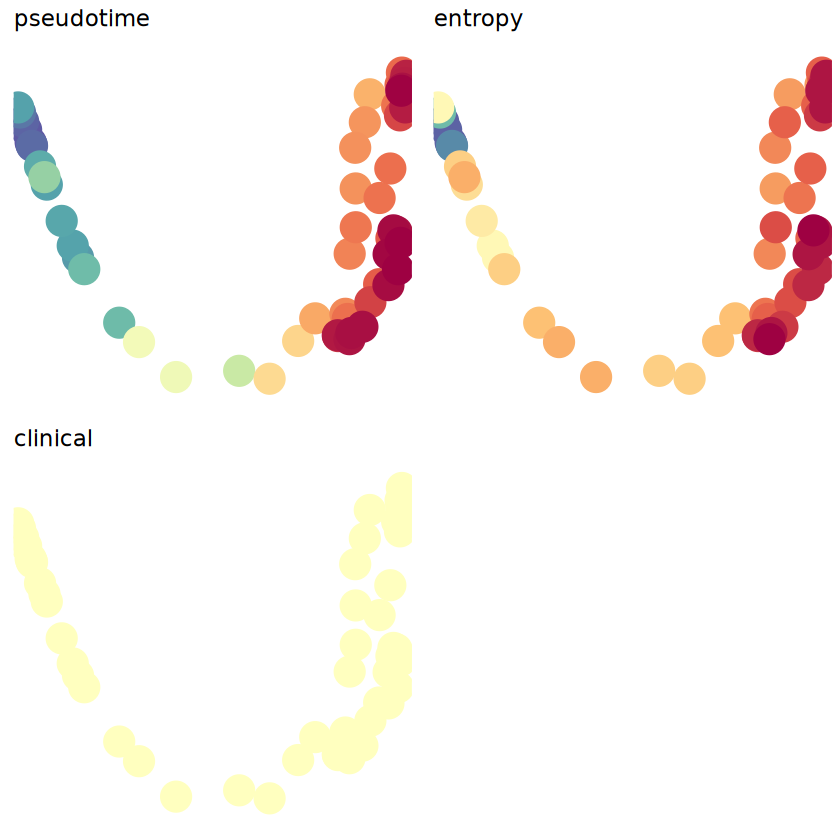

In [ ]:
plot.landscape(df, ncol=2, smoothened = F, 
               cols=color_pseudotime, 
               embedding = 'X_phate',
               legend.position = c(3,3), enforce.same.color.scale = F, size=8)

In [ ]:
ggsave('/projects/0/einf2548/cruiz/dmg/data/beyond/figures/phate_communities_pseudotime_DMG.pdf', 
      height=5, width=10)

In [ ]:
library(dendextend)
communities   <- data$uns$communities
membership    <- split(data$var_names, data$var$community)


---------------------
Welcome to dendextend version 1.17.1
Type citation('dendextend') for how to cite the package.

Type browseVignettes(package = 'dendextend') for the package vignette.
The github page is: https://github.com/talgalili/dendextend/

Suggestions and bug-reports can be submitted at: https://github.com/talgalili/dendextend/issues
You may ask questions at stackoverflow, use the r and dendextend tags: 
	 https://stackoverflow.com/questions/tagged/dendextend

	To suppress this message use:  suppressPackageStartupMessages(library(dendextend))
---------------------



Attaching package: ‘dendextend’


The following object is masked from ‘package:stats’:

    cutree




In [ ]:
# here had to change data$var_names for rownames(communities$dynamics.mtx) since order in data$var_namesis not the same!!!

# BE CAREFUL!!!!!
# Matrices were added to the anndata but we did not change the order to match the varn_names!!!

cell_order <- c("ac.6", "c1q.2", "cilia.7", "cop.1", "gb.5", "gw.2", "homeo.4", "il1b.5", "ipc.4", "lipid.3", "neumono.1", "opc.0", "rg.2", "scav.0", "td.3", "tri.1")

dynamics      <- communities$similarities$dynamics %>% `dimnames<-`(list(cell_order, communities$dynamics.colnames))
corr          <- communities$similarities$correlation %>% `dimnames<-`(list(cell_order, cell_order))
dyn.adjacency <- communities$similarities$dynamics.adjacency %>% `dimnames<-`(list(cell_order, cell_order))

In [ ]:
corr

,ac.6,c1q.2,cilia.7,cop.1,gb.5,gw.2,homeo.4,il1b.5,ipc.4,lipid.3,neumono.1,opc.0,rg.2,scav.0,td.3,tri.1
ac.6,1.00000000,-0.236331834,-0.01877875,0.11032517,-0.311259957,-0.53329029,0.7312256865,0.54886981,0.07465033,-0.6014749,-0.45701268,-0.0210369364,-0.19684306,-0.48063523,-0.42287437,0.30478125
c1q.2,-0.23633183,1.000000000,-0.09717492,-0.18094303,0.005698701,0.29100471,-0.1811818399,-0.37623626,-0.25491756,0.3856907,0.03562529,-0.1503235241,0.14777879,0.23566707,0.25847565,-0.07582277
cilia.7,-0.01877875,-0.097174918,1.00000000,0.21684376,0.537319532,-0.03458896,-0.1787534141,0.04424139,0.47794986,-0.1584714,0.32929930,0.0624745479,-0.08441327,0.26388060,-0.16202932,0.11627474
cop.1,0.11032517,-0.180943025,0.21684376,1.00000000,0.075248892,-0.13000229,0.0117627016,0.11508694,0.23773587,-0.3111061,0.10566087,0.3737386577,-0.22909369,0.28158349,-0.32138533,-0.13758797
gb.5,-0.31125996,0.005698701,0.53731953,0.07524889,1.000000000,0.09806407,-0.3790644948,-0.10671902,0.26758434,0.1044031,0.51713308,0.0751728933,0.02100709,0.29396233,0.09635240,-0.14480269
gw.2,-0.53329029,0.291004707,-0.03458896,-0.13000229,0.098064065,1.00000000,-0.5253532854,-0.44288596,-0.12996792,0.5467760,-0.00660134,-0.3373780260,0.45693242,0.35221813,0.22855855,0.04429924
homeo.4,0.73122569,-0.181181840,-0.17875341,0.01176270,-0.379064495,-0.52535329,1.0000000000,0.54590281,0.02923753,-0.5189909,-0.52303178,-0.0001971069,-0.26206024,-0.61744589,-0.22144658,0.31913049
il1b.5,0.54886981,-0.376236259,0.04424139,0.11508694,-0.106719023,-0.44288596,0.5459028139,1.00000000,0.22875097,-0.6899351,-0.16646697,0.1567234190,-0.27557850,-0.44004952,-0.35206668,0.16884959
ipc.4,0.07465033,-0.254917562,0.47794986,0.23773587,0.267584340,-0.12996792,0.0292375256,0.22875097,1.00000000,-0.3406169,0.14832138,0.1060591325,-0.17686581,0.11604350,0.02761661,0.18891134
lipid.3,-0.60147489,0.385690685,-0.15847141,-0.31110612,0.104403079,0.54677604,-0.5189909180,-0.68993511,-0.34061695,1.0000000,0.18599254,-0.1959605129,0.37302797,0.24463534,0.57551742,-0.18023652


data$var$sub.community <- recode(data$var$sub.community,
                                 'C1.2'='C1.1')
data$var

In [ ]:
# States to annotate
mark.states <- c('rg.2','gb.5','tri.1','ipc.4','opc.0','cop.1','ac.6','cilia.7','gw.2','td.3',
                 'neumono.1','c1q.2','lipid.3','scav.0','homeo.4','il1b.5')

hm.comms <- data$var %>% split(., as.character(.$community)) %>% 
  lapply(., function(inner) {
    
    if(any(!is.na(inner$sub.community))) 
      lst <- split(rownames(inner), as.character(inner$sub.community))
    else
      lst <- list(rownames(inner))
    
    lapply(lst, function(states) {
      mtx  <- dyn.adjacency[states,states] + corr[states,states]
      dend <- dendsort::dendsort(hclust(dist(mtx))) %>% as.dendrogram() %>% set("labels_to_character")
      
      prepare(Heatmap(dynamics[states,],
                      column_split =  factor(gsub("_.*", "", colnames(dynamics)), levels=c("clinical")),
                      cluster_rows = dend, 
                      cluster_row_slices = F,
                      cluster_columns = F,
                      show_column_names = F,
                      show_row_names = T,
                      show_row_dend = T,
                      row_dend_width = unit(10,"pt"),
                      col = circlize::colorRamp2(seq(-4,4,length.out=21), 
                                                 colorRampPalette(c("darkorchid4","white","#E65100"))(21)),
                      column_title = NULL,
                      row_names_side = "left",
                      column_gap = unit(1, "pt"),
                      right_annotation = rowAnnotation(states = anno_mark(which(rownames(mtx) %in% mark.states), intersect(rownames(mtx), mark.states)))))
      
    }) %>% unlist(., recursive=FALSE)
  })  %>% unlist(., recursive=FALSE)

In [ ]:
# Create annotations of traits and pseudotime
df <- data$uns$trajectories$palantir$dynamics$pred.vals %>% py_to_r(.) %>% 
  mutate(col=paste(trajectory, x, sep = "_"))
df

,x,fit,se.fit,fit_sd,se.fit_sd,feature,trajectory,col
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
0,0.00000000,0.9517585,0.06476212,NA,NA,ac.6,clinical,clinical_0
1,0.02040816,0.9307235,0.04908195,NA,NA,ac.6,clinical,clinical_0.0204081632653061
2,0.04081633,0.9103370,0.04334876,NA,NA,ac.6,clinical,clinical_0.0408163265306122
3,0.06122449,0.8915655,0.04503717,NA,NA,ac.6,clinical,clinical_0.0612244897959184
4,0.08163265,0.8753682,0.04684133,NA,NA,ac.6,clinical,clinical_0.0816326530612245
5,0.10204082,0.8625342,0.04591963,NA,NA,ac.6,clinical,clinical_0.102040816326531
6,0.12244898,0.8537430,0.04307629,NA,NA,ac.6,clinical,clinical_0.122448979591837
7,0.14285714,0.8496614,0.04019744,NA,NA,ac.6,clinical,clinical_0.142857142857143
8,0.16326531,0.8506172,0.03948689,NA,NA,ac.6,clinical,clinical_0.163265306122449


In [ ]:
color_pseudotime <- circlize::colorRamp2(
  seq(0, 1, length.out = 21), 
  rev(colorRampPalette(brewer.pal(11, "Spectral"))(21))
)(seq(0, 1, length.out = 21))

In [ ]:
pseudotime <- df %>% dplyr::select(col, x) %>% unique() %>% dcast(1~col, value.var = "x") %>% column_to_rownames("1") %>% `[`(,colnames(dynamics)) %>% as.matrix() 
pseudotime <- Heatmap(pseudotime,
                      col = color_pseudotime,
                      name = "pseudotime",
                      show_row_names = F,
                      show_column_names = F,
                      cluster_columns = F,
                      height = unit(.25,"cm"),
                      right_annotation = rowAnnotation(n=anno_mark(1, "pseudotime")))

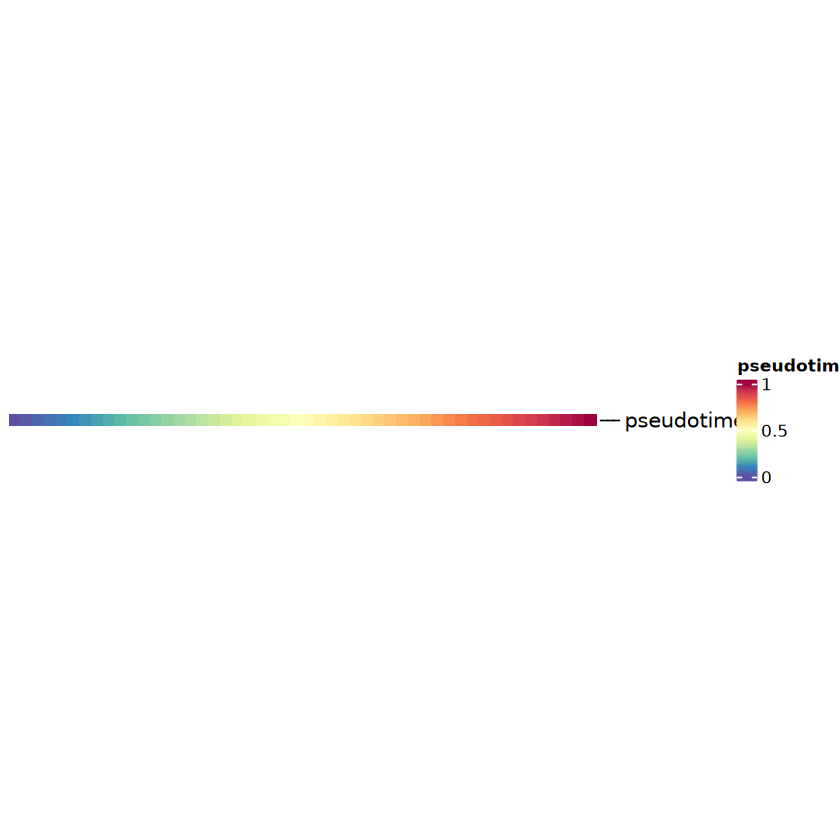

In [ ]:
pseudotime

In [ ]:
# Open a PDF device
pdf("/projects/0/einf2548/cruiz/dmg/data/beyond/figures/pseudotime_color_scale.pdf", width = 5, height = 2) # Adjust width and height as needed

# Draw the heatmap
draw(pseudotime)

# Close the PDF device
dev.off()

png 
  2

In [ ]:
state.order <- do.call(rbind, lapply(hm.comms, function(hm) data.frame(comm = hm@name, state=rownames(hm@matrix)[row_order(hm)])))
state.order

,comm,state
,<chr>,<chr>
C1.C1.1.1,matrix_1,ac.6
C1.C1.1.2,matrix_1,homeo.4
C1.C1.1.3,matrix_1,tri.1
C1.C1.2.1,matrix_2,ipc.4
C1.C1.2.2,matrix_2,il1b.5
C2.C2.1.1,matrix_3,rg.2
C2.C2.1.2,matrix_3,c1q.2
C2.C2.1.3,matrix_3,opc.0
C2.C2.2.1,matrix_4,gb.5


In [ ]:
dyn.adjacency <- dyn.adjacency[state.order$state, state.order$state]
corr <- corr[state.order$state, state.order$state]

marks <- sapply(mark.states, function(s) which(rownames(dyn.adjacency) == s))
matrices <- list(dyn.adjacency, corr)
# colors   <- list(circlize::colorRamp2(seq(0,1,length.out=21), colorRampPalette(c("white","salmon","red","firebrick4"))(21)),
#                  circlize::colorRamp2(seq(-1,1,length.out=21), green2purple.less.white(21)))

In [ ]:
library(viridis)  
library(RColorBrewer)
colors <- list(
  circlize::colorRamp2(seq(0, 1, length.out = 21), colorRampPalette(brewer.pal(11, "Reds"))(21)),
    circlize::colorRamp2(seq(-1, 1, length.out = 21), rev(colorRampPalette(brewer.pal(11, "RdBu"))(21)))
)

Warning message in brewer.pal(11, "Reds"):
“n too large, allowed maximum for palette Reds is 9
Returning the palette you asked for with that many colors
”


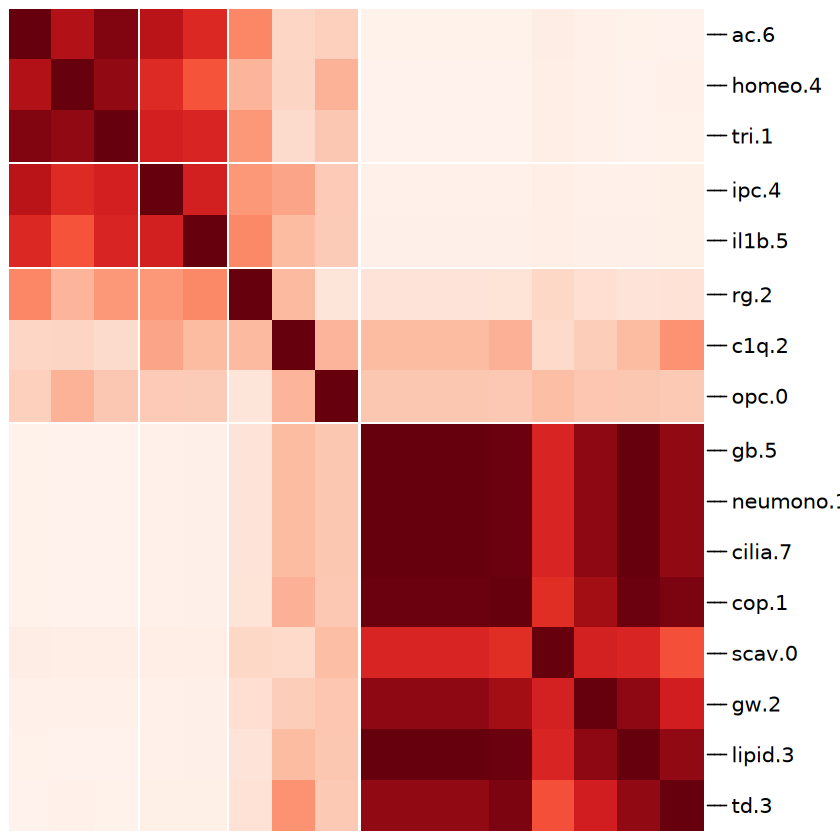

In [ ]:
 Heatmap(
    matrices[[1]],
    row_split = state.order$comm,
    column_split = state.order$comm,
    cluster_rows = F, 
    cluster_columns = F,
    col = colors[[1]],
    # cell_fun = function(j, i, x, y, w, h, col) {
    #   if(i==j) grid.rect(x,y,w,h, gp = gpar(fill="black", col=NA))
    # },
    column_title = NULL,
    row_title = NULL,
    show_heatmap_legend = F,
    show_row_names = F, 
    show_column_names = F,
    row_gap = unit(2, "pt"),
    column_gap = unit(2, "pt"),
    right_annotation = rowAnnotation(states = anno_mark(marks, names(marks)))
  ) %>% draw()

In [ ]:
# Open a PDF device
pdf("/projects/0/einf2548/cruiz/dmg/data/beyond/figures/multicellular_comunities_dynamics_similarity.pdf", width = 7.5, height = 7) # Adjust width and height as needed

Heatmap(
    matrices[[1]],
    row_split = state.order$comm,
    column_split = state.order$comm,
    cluster_rows = F, 
    cluster_columns = F,
    col = colors[[1]],
    # cell_fun = function(j, i, x, y, w, h, col) {
    #   if(i==j) grid.rect(x,y,w,h, gp = gpar(fill="black", col=NA))
    # },
    column_title = NULL,
    row_title = NULL,
    show_heatmap_legend = F,
    show_row_names = F, 
    show_column_names = F,
    row_gap = unit(2, "pt"),
    column_gap = unit(2, "pt"),
    right_annotation = rowAnnotation(states = anno_mark(marks, names(marks)))
  ) %>% draw()

# Close the PDF device
dev.off()

png 
  2

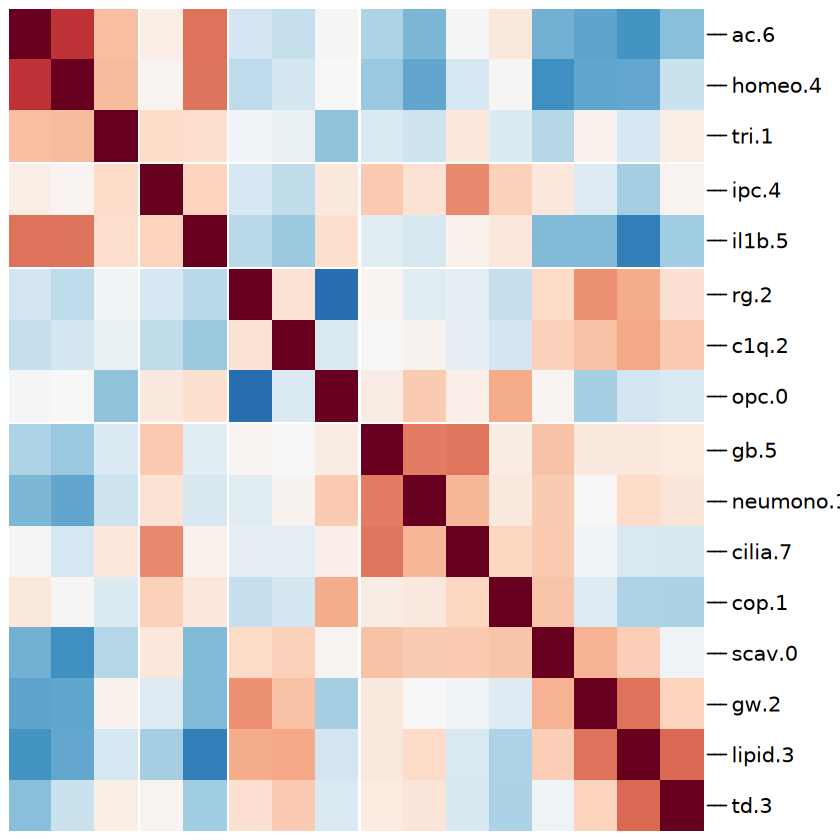

In [ ]:
 Heatmap(
    matrices[[2]],
    row_split = state.order$comm,
    column_split = state.order$comm,
    cluster_rows = F, 
    cluster_columns = F,
    col = colors[[2]],
    # cell_fun = function(j, i, x, y, w, h, col) {
    #   if(i==j) grid.rect(x,y,w,h, gp = gpar(fill="black", col=NA))
    # },
    column_title = NULL,
    row_title = NULL,
    show_heatmap_legend = F,
    show_row_names = F, 
    show_column_names = F,
    row_gap = unit(2, "pt"),
    column_gap = unit(2, "pt"),
    right_annotation = rowAnnotation(states = anno_mark(marks, names(marks)))
  ) %>% draw()

In [ ]:
# Open a PDF device
pdf("/projects/0/einf2548/cruiz/dmg/data/beyond/figures/multicellular_comunities_spearman_correlation.pdf", width = 7.5, height = 7) # Adjust width and height as needed

Heatmap(
    matrices[[2]],
    row_split = state.order$comm,
    column_split = state.order$comm,
    cluster_rows = F, 
    cluster_columns = F,
    col = colors[[2]],
    # cell_fun = function(j, i, x, y, w, h, col) {
    #   if(i==j) grid.rect(x,y,w,h, gp = gpar(fill="black", col=NA))
    # },
    column_title = NULL,
    row_title = NULL,
    show_heatmap_legend = F,
    show_row_names = F, 
    show_column_names = F,
    row_gap = unit(2, "pt"),
    column_gap = unit(2, "pt"),
    right_annotation = rowAnnotation(states = anno_mark(marks, names(marks)))
  ) %>% draw()

# Close the PDF device
dev.off()

png 
  2

In [ ]:
hm.comms <- data$var %>% split(., as.character(.$community)) %>% 
  lapply(., function(inner) {
    
    if(any(!is.na(inner$sub.community))) 
      lst <- split(rownames(inner), as.character(inner$sub.community))
    else
      lst <- list(rownames(inner))
    
    lapply(lst, function(states) {
      mtx  <- dyn.adjacency[states,states] + corr[states,states]
      dend <- dendsort::dendsort(hclust(dist(mtx))) %>% as.dendrogram() %>% set("labels_to_character")
      
      prepare(Heatmap(dynamics[states,],
                      column_split =  factor(gsub("_.*", "", colnames(dynamics)), levels=c("clinical")),
                      cluster_rows = dend, 
                      cluster_row_slices = F,
                      cluster_columns = F,
                      show_column_names = F,
                      show_row_names = T,
                      show_row_dend = T,
                      row_dend_width = unit(10,"pt"),
                      col = circlize::colorRamp2(seq(-4,4,length.out=21), 
                                                 colorRampPalette(c("#00dbdb", "white", "#db00db"))(21)),
                      column_title = NULL,
                      row_names_side = "left",
                      column_gap = unit(1, "pt"),
                      right_annotation = rowAnnotation(states = anno_mark(which(rownames(mtx) %in% mark.states), intersect(rownames(mtx), mark.states)))))
      
    }) %>% unlist(., recursive=FALSE)
  })  %>% unlist(., recursive=FALSE)

$C1.C1.1


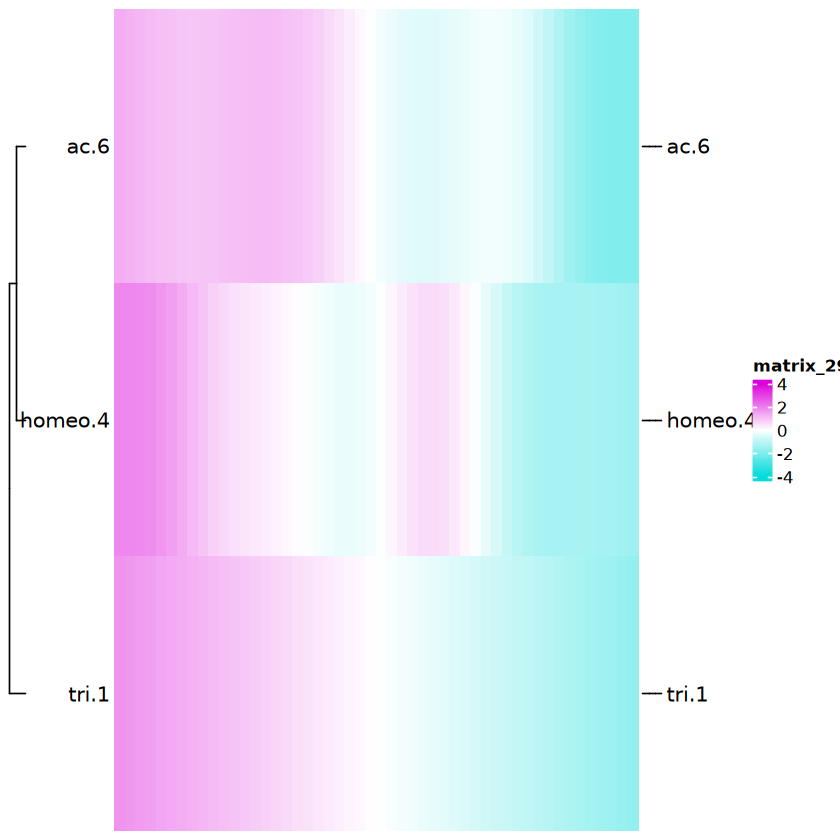

In [ ]:
hm.comms[1]

$C1.C1.2


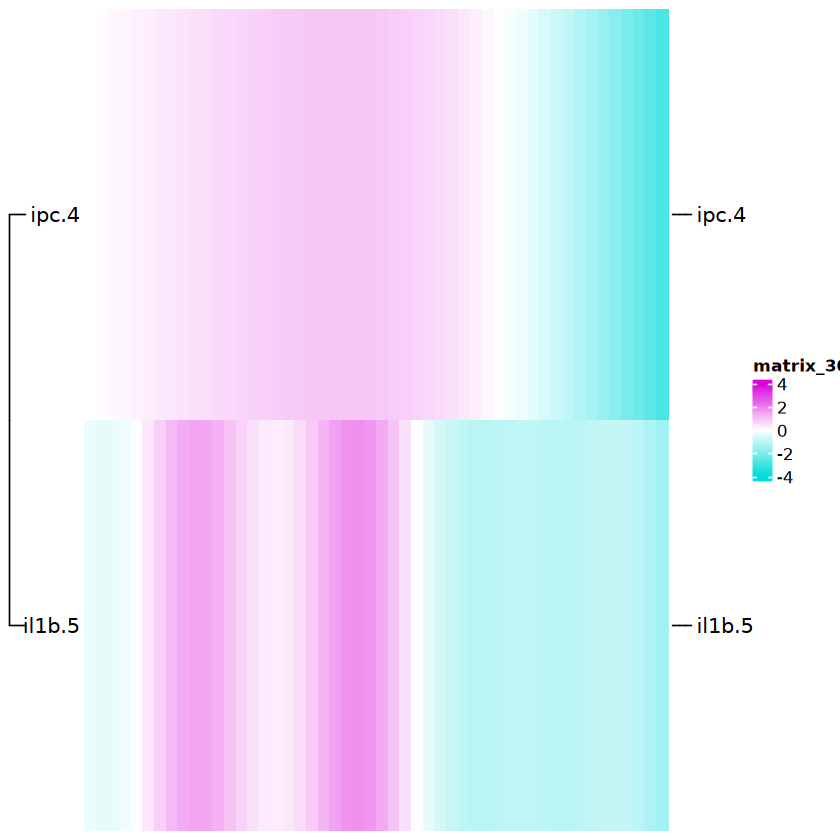

In [ ]:
hm.comms[2]

$C2.C2.1


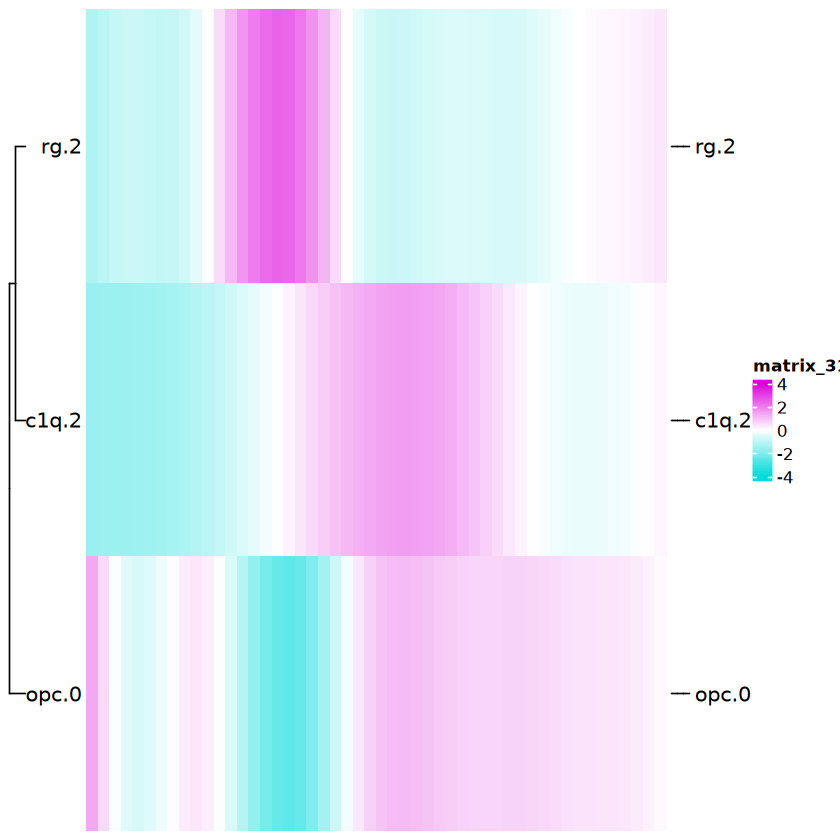

In [ ]:
hm.comms[3]

$C2.C2.2


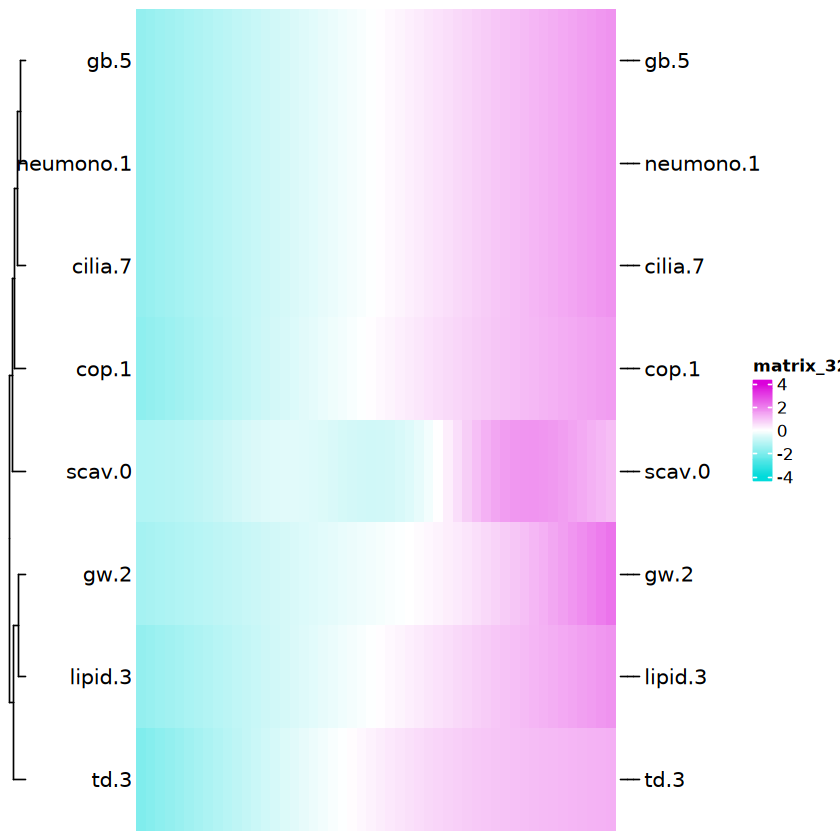

In [ ]:
hm.comms[4]

In [ ]:
# Iterate through each subplot in the list
for (i in seq_along(hm.comms)) {
  # Construct a file name for each subplot
  pdf_file <- file.path('/projects/0/einf2548/cruiz/dmg/data/beyond/figures/', 
                        paste0("heatmap_subplot_", i, ".pdf"))
  
  # Open a PDF device
  pdf(pdf_file, width = 10, height = 8) # Adjust the size as needed
  
  # Draw the heatmap
  draw(hm.comms[[i]])
  
  # Close the PDF device
  dev.off()
}

Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2 3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”


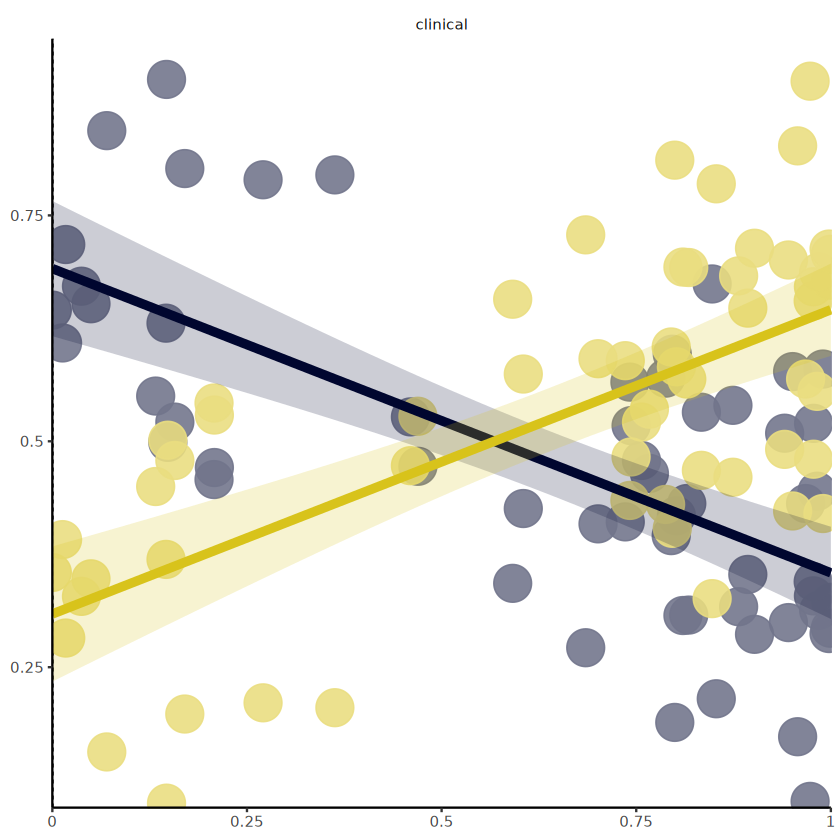

In [ ]:
plot.dynamics(c("C1", "C2"), dynamics = data$uns$communities$dynamics, size=10,
              cols = list(C2="#d8c31b", C1="#00062f"), include.points = TRUE,  
              legend.position = c(3,3), overlap.pseudotime = 0) + labs(x=NULL, y=NULL)

In [ ]:
ggsave('/projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_C1_C2.pdf', 
      height=7, width=10)

In [ ]:
state.dynamics.sets <- list(
    list(rg.2="#74150f", gb.5="#474747", opc.0="#c13910", td.3='#ba7db3', ipc.4='#fdc955', cop.1='#f4e5e1'),
    list(neumono.1="#00a69c", c1q.2="#165884"),
    list(ac.6="#caa4ab", homeo.4="#26a9e0", il1b.5 = "#343682"),
    list(lipid.3="#7b7dba", gw.2 = "#5c2454", scav.0="#95bbcd"))

In [ ]:
state.dynamics.sets <- list(
    list(ac.6="#caa4ab", homeo.4="#26a9e0", tri.1 = "#b26671"),
    list(ipc.4='#fdc955', il1b.5 = "#343682"),
    list(rg.2="#74150f", opc.0="#c13910", c1q.2="#165884"),
    list(neumono.1="#00a69c", gb.5="#474747", cop.1='#f4e5e1', cilia.7='#9a9b06', scav.0="#95bbcd"),
    list(lipid.3="#7b7dba", gw.2 = "#5c2454", td.3='#ba7db3')
)

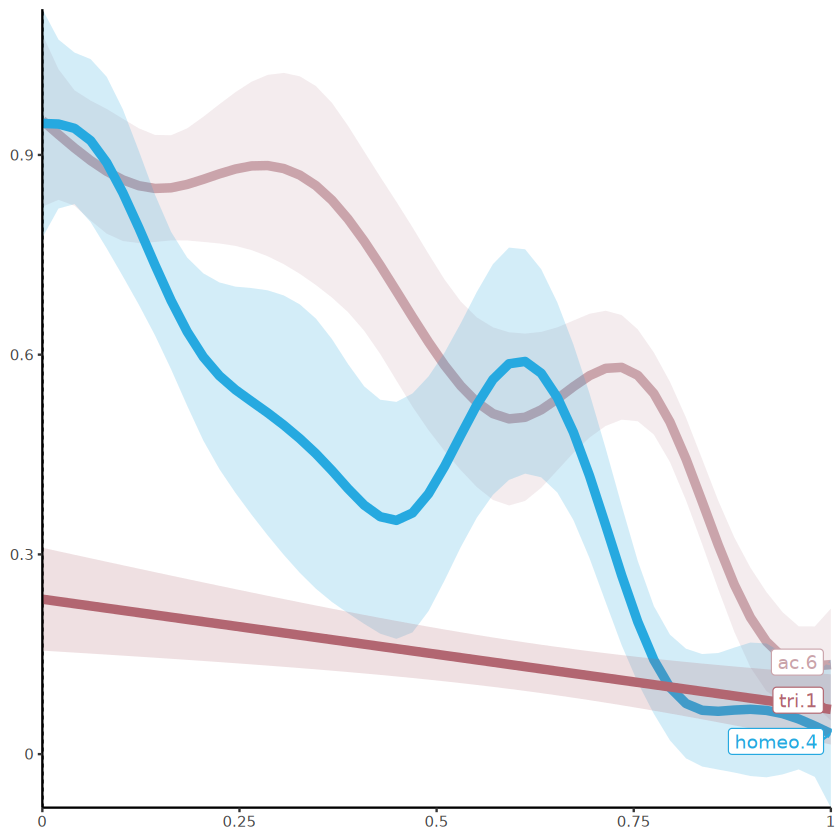

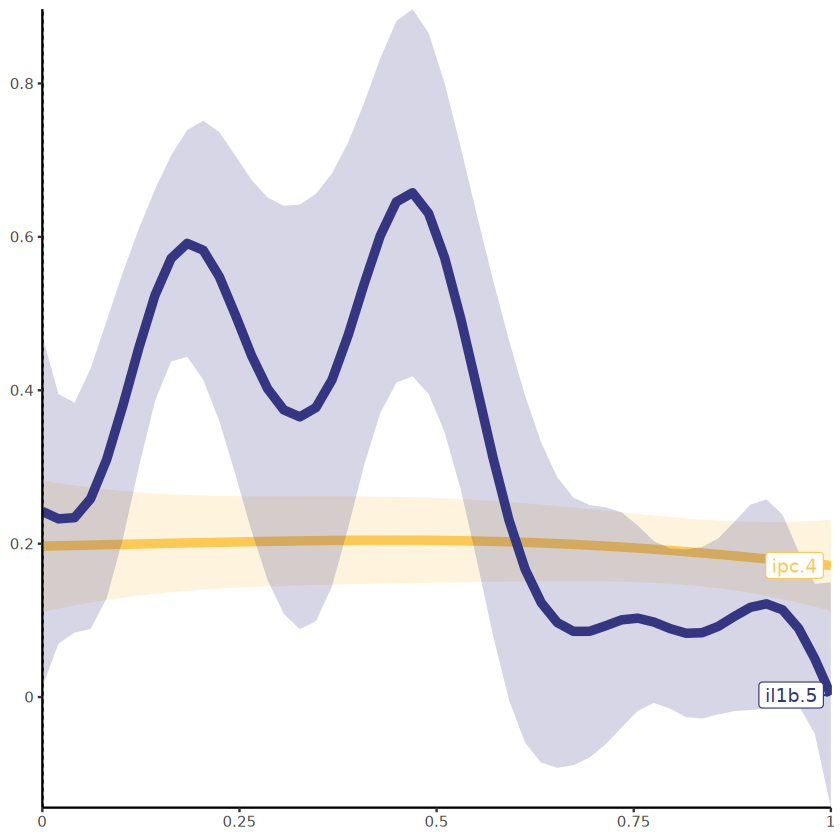

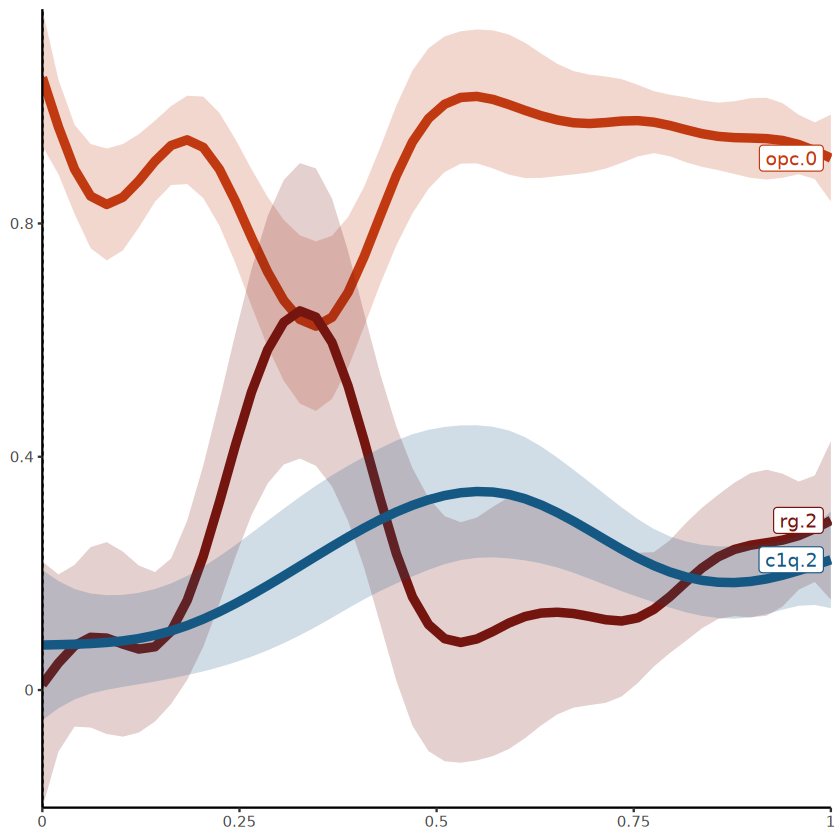

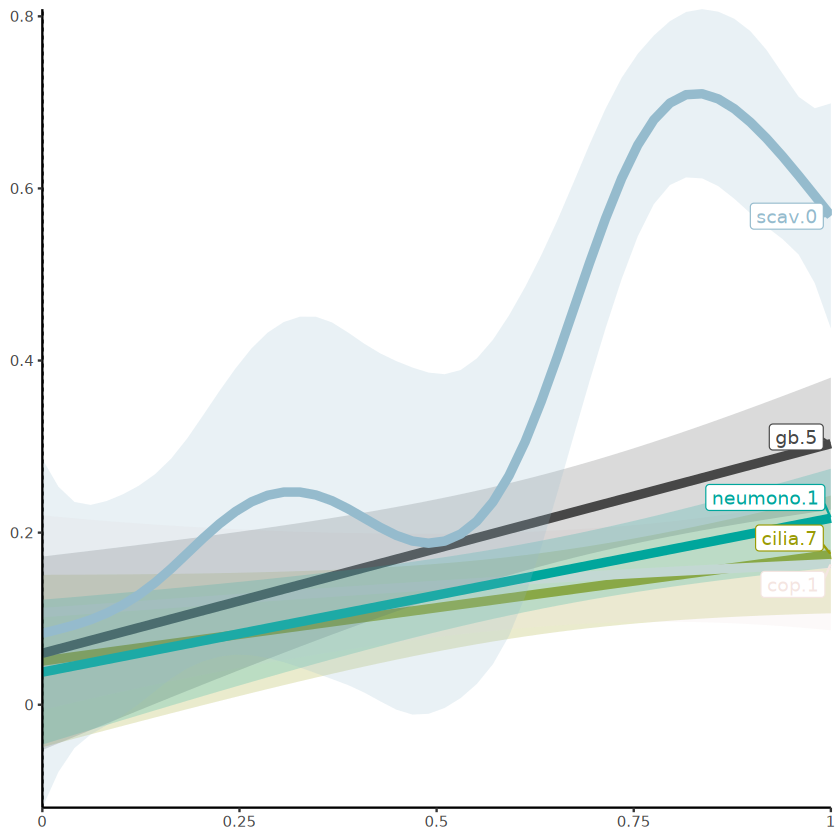

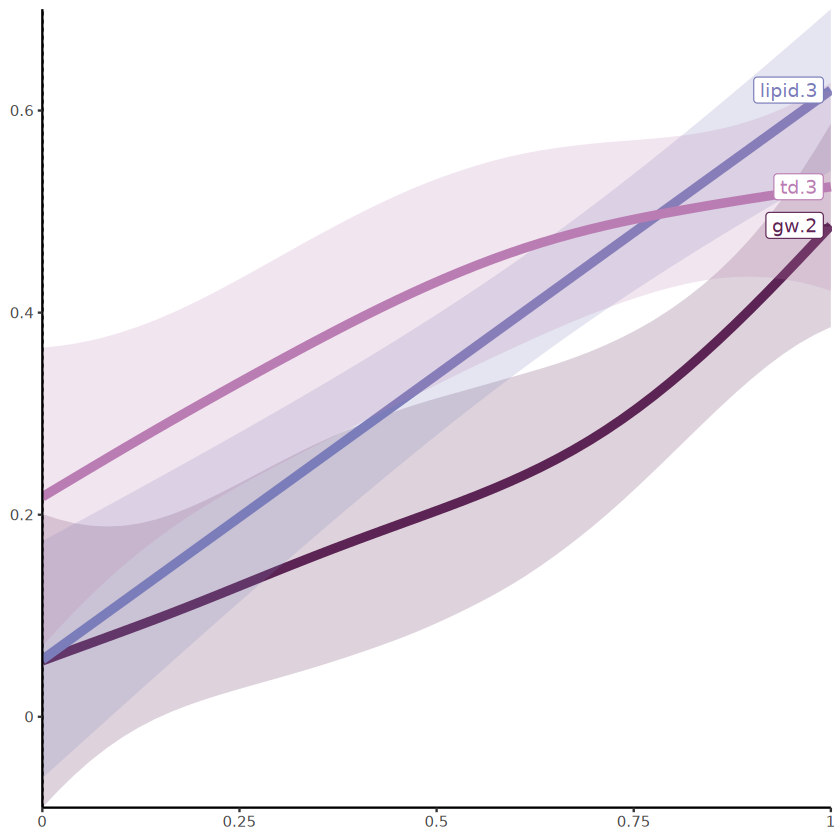

In [ ]:
for(states in state.dynamics.sets) {
  print(plot.dynamics(names(states), cols = states, overlap.pseudotime=0, label=TRUE) + 
    theme(strip.text = element_blank(), 
          legend.position="none", 
          axis.line = element_line(), 
          axis.text.y = element_text()) + 
    labs(x=NULL, y=NULL, title=NULL))
}

In [ ]:
# Loop through the states and save each plot to the PDF
for (states in state.dynamics.sets) {
  plot.dynamics(names(states), cols = states, overlap.pseudotime = 0, label = TRUE) + 
    theme(strip.text = element_blank(), 
          legend.position = "none", 
          axis.line = element_line(), 
          axis.text.y = element_text()) + 
    labs(x = NULL, y = NULL, title = NULL)
  
  ggsave(paste0('/projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_per_cell_type_', states, '_FINAL.pdf'), 
      height=5, width=5)
}

Warning message in ggsave(paste0("/projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_per_cell_type_", :
“`filename` must have length 1, not 3.
! Only the first, /projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_per_cell_type_#caa4ab_FINAL.pdf, will be
  used.”
Warning message in ggsave(paste0("/projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_per_cell_type_", :
“`filename` must have length 1, not 2.
! Only the first, /projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_per_cell_type_#fdc955_FINAL.pdf, will be
  used.”
Warning message in ggsave(paste0("/projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_per_cell_type_", :
“`filename` must have length 1, not 3.
! Only the first, /projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_per_cell_type_#74150f_FINAL.pdf, will be
  used.”
Warning message in ggsave(paste0("/projects/0/einf2548/cruiz/dmg/data/beyond/figur